In [1]:
# Install required libraries
%pip install numpy pandas matplotlib scipy requests yfinance

  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached cffi-2.0.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.6 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [29]:
%pip install yfinance pandas numpy matplotlib pyarrow


  Using cached pyarrow-23.0.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (3.1 kB)
Using cached pyarrow-23.0.1-cp314-cp314-macosx_12_0_arm64.whl (34.2 MB)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1

In [39]:
# Install required dependencies if you haven't already
# !pip install yfinance pandas numpy matplotlib pyarrow

import yfinance as yf
import pandas as pd
import numpy as np
import os

# --- PHASE 1: VIX Daily Data Acquisition ---
print("Downloading VIX daily data (Jan 2019 - Apr 2020)...")
vix = yf.download("^VIX", start="2019-01-01", end="2020-05-01")

# Clean multi-index columns if yfinance returns them
if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.get_level_values(0)

# Keep only the Close price
vix_daily = vix[['Close']].copy()
vix_daily.index = pd.to_datetime(vix_daily.index).date
vix_daily.columns = ['vix_close']
print(f"Successfully downloaded {len(vix_daily)} VIX records.")
vix_daily.head()

[*********************100%***********************]  1 of 1 completed

Successfully downloaded 335 VIX records.


,vix_close
2019-01-02,23.219999
2019-01-03,25.450001
2019-01-04,21.379999
2019-01-07,21.400000
2019-01-08,20.469999


## 2

In [40]:
# --- PHASE 2: VIX Labeling ---
def label_vix(v):
    if v < 15: return "Quiet"
    elif v <= 25: return "Trending"
    else: return "Crash"

vix_daily['regime'] = vix_daily['vix_close'].apply(label_vix)

print("Initial VIX Regime Distribution:")
regime_counts = vix_daily['regime'].value_counts()
print(regime_counts)

# Adaptive Threshold Check
if regime_counts.get("Quiet", 0) < 30: 
    print("\n[!] 'Quiet' regime is critically low. Adjusting threshold to VIX < 18 as per contingency plan.")
    def label_vix_adjusted(v):
        if v < 18: return "Quiet"
        elif v <= 25: return "Trending"
        else: return "Crash"
    vix_daily['regime'] = vix_daily['vix_close'].apply(label_vix_adjusted)
    print("\nAdjusted VIX Regime Distribution:")
    print(vix_daily['regime'].value_counts())

# Save to CSV instead of Parquet to bypass the pyarrow error
vix_daily.to_csv("vix_daily.csv")
print("\nSaved to vix_daily.csv")

Initial VIX Regime Distribution:
regime
Quiet       154
Trending    132
Crash        49
Name: count, dtype: int64

Saved to vix_daily.csv


## 3

In [78]:
import os
import pandas as pd

# --- PHASE 1: Dukascopy Tick Ingestion ---
FILE_PATH = "download/eurusd-tick-2020-01-01-2020-04-30.csv" 

if os.path.exists(FILE_PATH):
    print("Loading real Dukascopy data (this may take a minute on M1)...")
    tick_df = pd.read_csv(FILE_PATH)
    
    # Strip any accidental whitespace from column names
    tick_df.columns = tick_df.columns.str.strip()
    
    print("Parsing timestamps to datetime objects...")
    # FIX: Tell Pandas the integers are in milliseconds!
    tick_df['timestamp'] = pd.to_datetime(tick_df['timestamp'], unit='ms')
    
    # Dukascopy often attaches a UTC timezone. We remove it to align cleanly with our VIX dates.
    if getattr(tick_df['timestamp'].dt, 'tz', None) is not None:
        tick_df['timestamp'] = tick_df['timestamp'].dt.tz_convert(None)
        
else:
    raise FileNotFoundError(f"Could not find the file at {FILE_PATH}. Please check the path!")

# Extract calendar date for alignment
tick_df['date'] = tick_df['timestamp'].dt.date
print(f"Successfully loaded {len(tick_df)} ticks.")
tick_df.head()

Loading real Dukascopy data (this may take a minute on M1)...
Parsing timestamps to datetime objects...
Successfully loaded 11473508 ticks.


,timestamp,askPrice,bidPrice,date
0,2020-01-01 22:01:12.821,1.12160,1.12106,2020-01-01
1,2020-01-01 22:01:17.176,1.12160,1.12120,2020-01-01
2,2020-01-01 22:01:18.545,1.12160,1.12117,2020-01-01
3,2020-01-01 22:01:19.145,1.12161,1.12123,2020-01-01
4,2020-01-01 22:01:19.246,1.12161,1.12120,2020-01-01


## 4

In [79]:
# --- PHASE 2: Tick Alignment (Time-Squish Fix) ---
print("Aligning ticks with VIX regimes...")

# 1. Match dates
tick_df['date'] = pd.to_datetime(tick_df['date']).dt.date
if 'date' not in vix_daily.columns:
    vix_daily = vix_daily.reset_index()
vix_daily['date'] = pd.to_datetime(vix_daily['Date'] if 'Date' in vix_daily.columns else vix_daily['index']).dt.date

# 2. Merge
tick_df = tick_df.merge(vix_daily[['date', 'regime']], on='date', how='inner')

# 3. THE FIX: Safely calculate fractional seconds since epoch
epoch = pd.Timestamp("1970-01-01")
tick_df['timestamp_sec'] = (tick_df['timestamp'] - epoch).dt.total_seconds()

# 4. Handle simultaneous trades
duplicates = tick_df.duplicated(subset=['timestamp'], keep='last')
num_dropped = duplicates.sum()
tick_df = tick_df[~duplicates].reset_index(drop=True)
print(f"Dropped {num_dropped} simultaneous ticks.")

# 5. Sort
tick_df = tick_df.sort_values(by=['date', 'timestamp_sec']).reset_index(drop=True)
print("\nFinal Merged Tick Regime Distribution:")
print(tick_df['regime'].value_counts())

Aligning ticks with VIX regimes...
Dropped 0 simultaneous ticks.

Final Merged Tick Regime Distribution:
regime
Crash       8659572
Quiet       1605305
Trending     856147
Name: count, dtype: int64


## 5&6

In [80]:
from scipy.optimize import minimize
import numpy as np

# --- PHASE 3: Robust Dataset Split & Stitching ---
print("Splitting and stitching datasets (with strict dt > 0 enforcement)...")

def extract_and_stitch_robust(df, regime_name, max_events=50000):
    regime_df = df[df['regime'] == regime_name].copy()
    stitched_timestamps = []
    current_t_offset = 0.0
    
    for date, group in regime_df.groupby('date'):
        # np.unique naturally sorts and eliminates any exact duplicate float times
        ts = np.unique(group['timestamp_sec'].values) 
        
        if len(ts) > 1:
            ts_zeroed = ts - ts[0]
            ts_shifted = ts_zeroed + current_t_offset
            stitched_timestamps.extend(ts_shifted)
            current_t_offset = ts_shifted[-1] + 1.0 # 1 sec gap between stitched days
            
        if len(stitched_timestamps) >= max_events:
            stitched_timestamps = stitched_timestamps[:max_events]
            break
            
    ts_array = np.array(stitched_timestamps)
    
    # Diagnostic to prove the data makes sense
    T = ts_array[-1] - ts_array[0]
    empirical_mu = len(ts_array) / T
    print(f"[{regime_name}] Extracted {len(ts_array)} events spanning {T:.2f} seconds. (Avg {empirical_mu:.2f} ticks/sec)")
    
    return ts_array

ts_quiet = extract_and_stitch_robust(tick_df, "Quiet")
ts_trending = extract_and_stitch_robust(tick_df, "Trending")
ts_crash = extract_and_stitch_robust(tick_df, "Crash")


# --- PHASE 4: Bounded MLE Fitting ---
def hawkes_loglik(params, timestamps):
    mu, alpha, beta = params
    T = timestamps[-1] - timestamps[0]
    n = len(timestamps)
    
    lam = np.zeros(n)
    R = 0.0
    for i in range(n):
        if i > 0:
            dt = timestamps[i] - timestamps[i-1]
            # If dt is somehow 0, clip it to 1 microsecond to prevent R explosion
            dt = max(dt, 1e-6) 
            R = np.exp(-beta * dt) * (1 + R)
        lam[i] = mu + alpha * R
        
    lam = np.clip(lam, 1e-10, None)
    loglik = np.sum(np.log(lam)) - mu * T - (alpha/beta) * np.sum(1 - np.exp(-beta * (timestamps[-1] - timestamps)))
    return -loglik 

def fit_hawkes_bounded(timestamps):
    best_val = np.inf
    best_res = None
    
    # Scaled down grid seeds closer to physical reality
    mu_grid = [0.5, 2.0, 5.0]
    alpha_grid = [1.0, 10.0]
    beta_grid = [5.0, 20.0]
    
    # HARD BOUNDS: Force the optimizer to stay in reality.
    # mu <= 100, alpha <= 5000, beta <= 5000
    bnds = ((1e-4, 100.0), (1e-4, 5000.0), (1e-4, 5000.0))
    cons = ({'type': 'ineq', 'fun': lambda x: 1.0 - (x[1] / x[2]) - 1e-4})
    
    for m in mu_grid:
        for a in alpha_grid:
            for b in beta_grid:
                if a >= b: continue 
                
                x0 = [m, a, b]
                res = minimize(hawkes_loglik, x0, args=(timestamps,), 
                               method='SLSQP', bounds=bnds, constraints=cons)
                
                if res.success and res.fun < best_val:
                    best_val = res.fun
                    best_res = res
                    
    return best_res.x if best_res is not None else [np.nan, np.nan, np.nan]

print("\nFitting Hawkes parameters with Strict Bounds (this will be fast)...")
theta_quiet = fit_hawkes_bounded(ts_quiet)
theta_trending = fit_hawkes_bounded(ts_trending)
theta_crash = fit_hawkes_bounded(ts_crash)

print("\n--- Final Bounded Hawkes Parameters ---")
thetas = {"Quiet": theta_quiet, "Trending": theta_trending, "Crash": theta_crash}

for name, theta in thetas.items():
    mu, alpha, beta = theta
    n_ratio = alpha / beta
    status = "✓" if n_ratio < 1.0 else "✗ EXPLOSIVE"
    print(f"{name.ljust(10)}: µ={mu:.4f}, α={alpha:.4f}, β={beta:.4f} | Branching Ratio (n)={n_ratio:.4f} {status}")

Splitting and stitching datasets (with strict dt > 0 enforcement)...
[Quiet] Extracted 50000 events spanning 54895.57 seconds. (Avg 0.91 ticks/sec)
[Trending] Extracted 50000 events spanning 55919.16 seconds. (Avg 0.89 ticks/sec)
[Crash] Extracted 50000 events spanning 47441.68 seconds. (Avg 1.05 ticks/sec)

Fitting Hawkes parameters with Strict Bounds (this will be fast)...

--- Final Bounded Hawkes Parameters ---
Quiet     : µ=0.3558, α=1.4599, β=2.3955 | Branching Ratio (n)=0.6094 ✓
Trending  : µ=0.3002, α=1.3014, β=1.9589 | Branching Ratio (n)=0.6643 ✓
Crash     : µ=0.3755, α=1.5243, β=2.3680 | Branching Ratio (n)=0.6437 ✓


## 7

In [81]:
import scipy.stats as stats

# --- PHASE 5: Validation (AIC/BIC & KS Test) ---
print("Running Phase 5 Validations...\n")

def run_validation(timestamps, theta, regime_name):
    mu, alpha, beta = theta
    n_events = len(timestamps)
    T = timestamps[-1] - timestamps[0]
    
    # 1. Baseline Poisson Model
    mu_poisson = n_events / T
    ll_poisson = n_events * np.log(mu_poisson) - mu_poisson * T
    
    # 2. Hawkes Log-Likelihood (Exact)
    lam = np.zeros(n_events)
    R = 0.0
    for i in range(n_events):
        if i > 0:
            dt = timestamps[i] - timestamps[i-1]
            dt = max(dt, 1e-6)
            R = np.exp(-beta * dt) * (1 + R)
        lam[i] = mu + alpha * R
    
    ll_hawkes = np.sum(np.log(np.clip(lam, 1e-10, None))) - mu * T - (alpha/beta) * np.sum(1 - np.exp(-beta * (timestamps[-1] - timestamps)))
    
    # 3. AIC / BIC Calculation
    aic_hawkes = 2 * 3 - 2 * ll_hawkes
    bic_hawkes = 3 * np.log(n_events) - 2 * ll_hawkes
    
    aic_poisson = 2 * 1 - 2 * ll_poisson
    bic_poisson = 1 * np.log(n_events) - 2 * ll_poisson
    
    print(f"--- {regime_name} Regime ---")
    print(f"Hawkes LL:  {ll_hawkes:.2f} | AIC: {aic_hawkes:.2f} | BIC: {bic_hawkes:.2f}")
    print(f"Poisson LL: {ll_poisson:.2f} | AIC: {aic_poisson:.2f} | BIC: {bic_poisson:.2f}")
    print(f"Model Selection: {'Hawkes Wins ✓' if aic_hawkes < aic_poisson else 'Poisson Wins ✗ (No Self-Excitation)'}")
    
    # 4. Time-Rescaling Theorem (KS Test) with Correct Compensator
    compensators = []
    R_ks = 0.0
    for i in range(1, n_events):
        dt = timestamps[i] - timestamps[i-1]
        dt = max(dt, 1e-6)
        
        # Integral of intensity from t_{i-1} to t_i
        Lambda_i = mu * dt + (alpha / beta) * (R_ks + 1) * (1 - np.exp(-beta * dt))
        compensators.append(Lambda_i)
        
        # Update R for the next step
        R_ks = np.exp(-beta * dt) * (R_ks + 1)
        
    # Transform to Uniform(0,1)
    U = 1 - np.exp(-np.array(compensators))
    stat, pval = stats.kstest(U, 'uniform')
    print(f"KS Test p-value: {pval:.4f} ({'Good Fit ✓' if pval > 0.05 else 'Reject Fit ✗'})\n")

run_validation(ts_quiet, theta_quiet, "Quiet")
run_validation(ts_trending, theta_trending, "Trending")
run_validation(ts_crash, theta_crash, "Crash")

Running Phase 5 Validations...

--- Quiet Regime ---
Hawkes LL:  -37127.70 | AIC: 74261.39 | BIC: 74287.85
Poisson LL: -54670.48 | AIC: 109342.97 | BIC: 109351.79
Model Selection: Hawkes Wins ✓
KS Test p-value: 0.0000 (Reject Fit ✗)

--- Trending Regime ---
Hawkes LL:  -36205.48 | AIC: 72416.95 | BIC: 72443.41
Poisson LL: -55594.21 | AIC: 111190.41 | BIC: 111199.23
Model Selection: Hawkes Wins ✓
KS Test p-value: 0.0000 (Reject Fit ✗)

--- Crash Regime ---
Hawkes LL:  -30485.71 | AIC: 60977.43 | BIC: 61003.89
Poisson LL: -47373.90 | AIC: 94749.81 | BIC: 94758.63
Model Selection: Hawkes Wins ✓
KS Test p-value: 0.0000 (Reject Fit ✗)



## 8

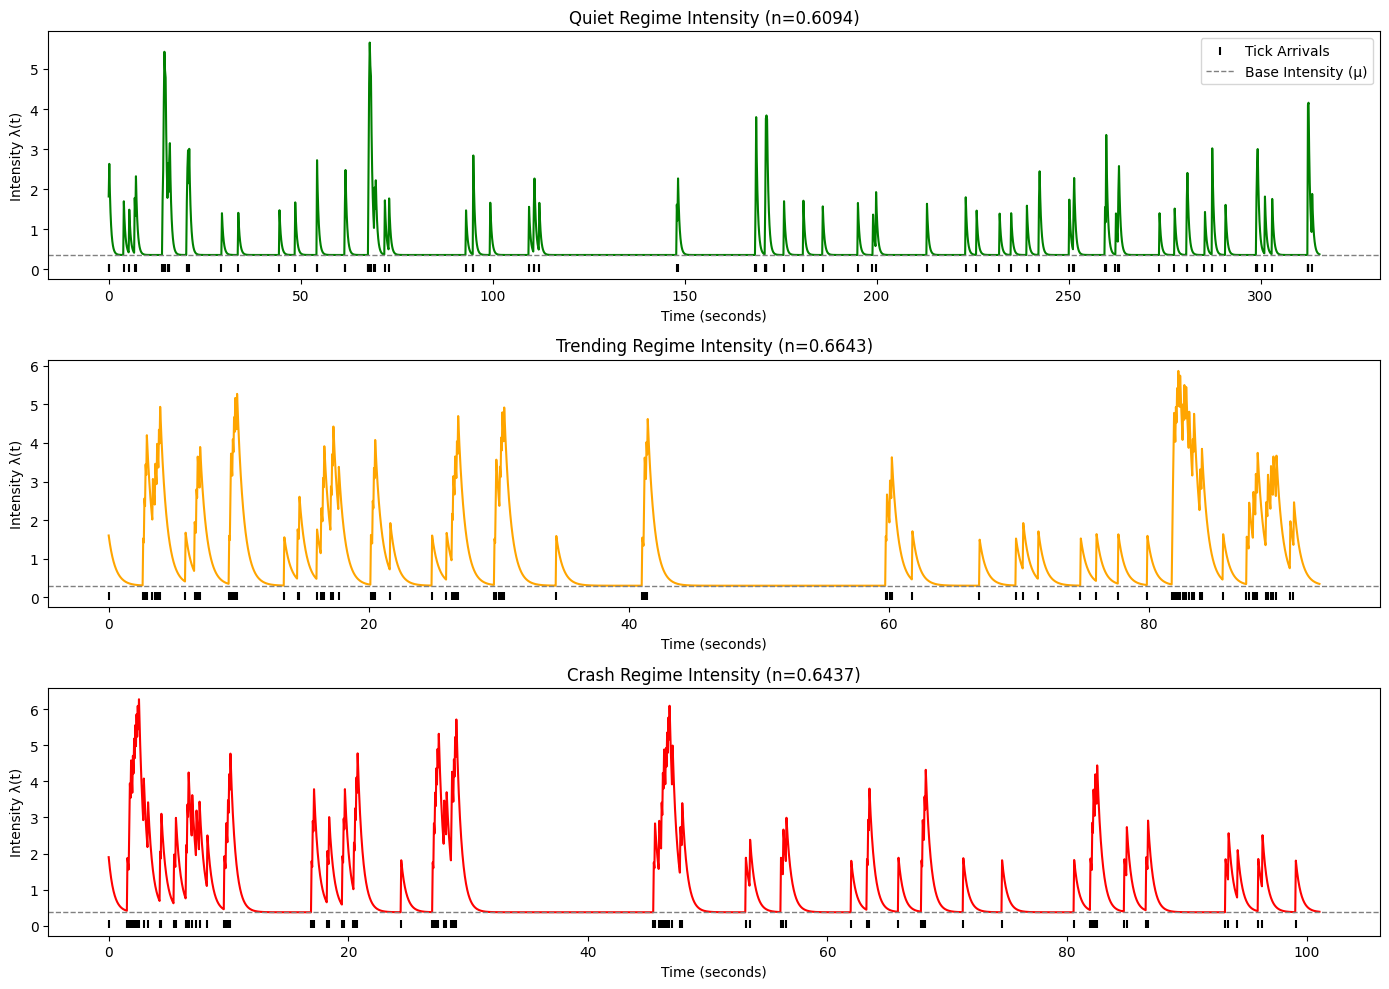

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# --- PHASE 6: λ(t) Intensity Plot (FIXED) ---

def plot_intensity(timestamps, theta, ax, color, title):
    mu, alpha, beta = theta
    
    # Take a 100-event slice to make the bursts visually distinguishable
    if len(timestamps) > 100:
        ts_slice = timestamps[1000:1100] 
    else:
        ts_slice = timestamps
        
    ts_slice = ts_slice - ts_slice[0] # Re-zero for the plot
    
    # Create a dense time grid for smooth exponential decay curves
    t_grid = np.linspace(0, ts_slice[-1] + 2, 2000)
    lambda_t = np.full_like(t_grid, mu)
    
    # Calculate intensity at every point on the dense grid
    for t_i in ts_slice:
        mask = t_grid >= t_i
        lambda_t[mask] += alpha * np.exp(-beta * (t_grid[mask] - t_i))
        
    ax.plot(t_grid, lambda_t, color=color, linewidth=1.5)
    ax.scatter(ts_slice, np.full_like(ts_slice, mu * 0.1), color='black', marker='|', zorder=3, label="Tick Arrivals")
    ax.axhline(mu, color='gray', linestyle='--', linewidth=1, label="Base Intensity (µ)")
    ax.set_title(title)
    ax.set_ylabel("Intensity λ(t)")
    ax.set_xlabel("Time (seconds)") # Set for every subplot since sharex=False

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

plot_intensity(ts_quiet, theta_quiet, axes[0], "green", f"Quiet Regime Intensity (n={theta_quiet[1]/theta_quiet[2]:.4f})")
plot_intensity(ts_trending, theta_trending, axes[1], "orange", f"Trending Regime Intensity (n={theta_trending[1]/theta_trending[2]:.4f})")
plot_intensity(ts_crash, theta_crash, axes[2], "red", f"Crash Regime Intensity (n={theta_crash[1]/theta_crash[2]:.4f})")

axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

Running Sliding Window Inference (Feb 2020 - Apr 2020)...
Generated 38208 window predictions.

Validating against VIX ground truth...


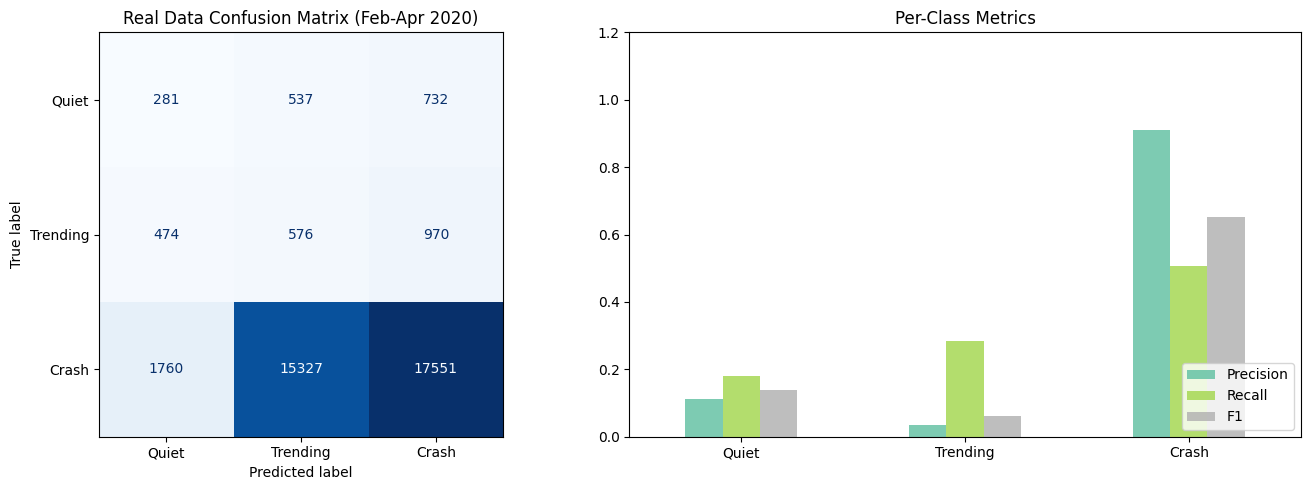


--- Final Classification Report ---
              precision    recall  f1-score   support

       Quiet       0.11      0.18      0.14      1550
    Trending       0.04      0.29      0.06      2020
       Crash       0.91      0.51      0.65     34638

    accuracy                           0.48     38208
   macro avg       0.35      0.32      0.28     38208
weighted avg       0.83      0.48      0.60     38208



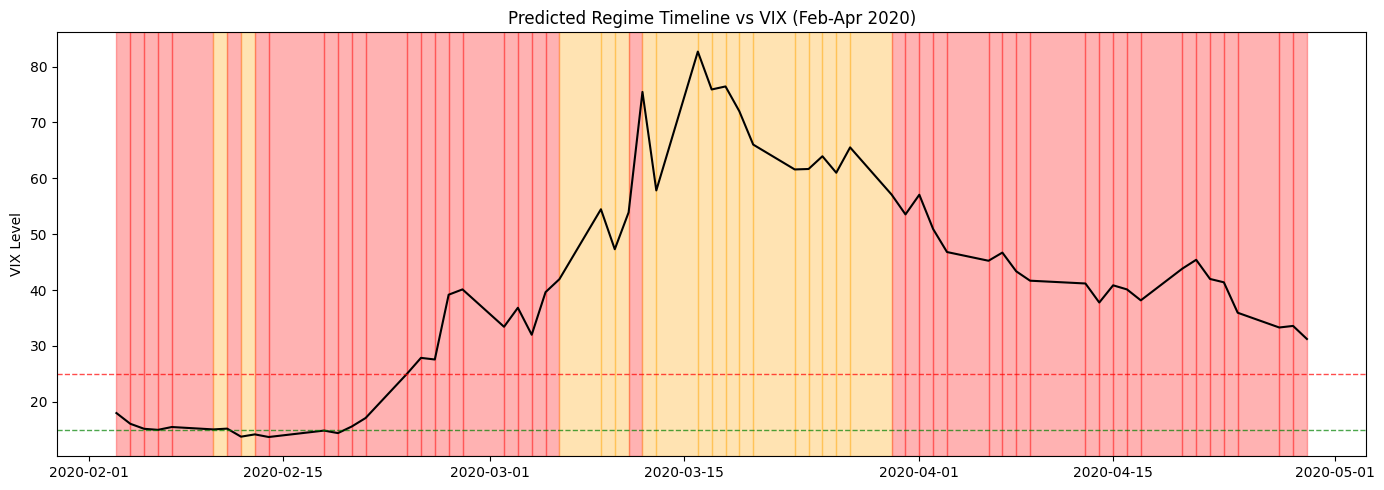

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# --- PHASE 7: Sliding Window Inference ---
print("Running Sliding Window Inference (Feb 2020 - Apr 2020)...")

# Fast Log-Likelihood function for window inference
def compute_window_ll(timestamps, theta):
    mu, alpha, beta = theta
    T = timestamps[-1] - timestamps[0]
    if T <= 0: return -np.inf 
    n = len(timestamps)
    
    lam = np.zeros(n)
    R = 0.0
    for i in range(n):
        if i > 0:
            dt = max(timestamps[i] - timestamps[i-1], 1e-6)
            R = np.exp(-beta * dt) * (1 + R)
        lam[i] = mu + alpha * R
        
    lam = np.clip(lam, 1e-10, None)
    return np.sum(np.log(lam)) - mu * T - (alpha/beta) * np.sum(1 - np.exp(-beta * (timestamps[-1] - timestamps)))

# 1. Create the Hold-out Set (Feb 1, 2020 onwards to capture the crash)
holdout_df = tick_df[tick_df['date'] >= pd.to_datetime('2020-02-01').date()].copy()
holdout_timestamps = holdout_df['timestamp_sec'].values
holdout_dates = holdout_df['date'].values

window_size = 500
step_size = 250 # 50% overlap

results = []
thetas = [theta_quiet, theta_trending, theta_crash]
regime_names = ["Quiet", "Trending", "Crash"]

# Slide the window
for start_idx in range(0, len(holdout_timestamps) - window_size, step_size):
    end_idx = start_idx + window_size
    window_ts = holdout_timestamps[start_idx:end_idx]
    
    # Re-zero the window for LL calculation
    window_ts_zeroed = window_ts - window_ts[0]
    
    scores = [compute_window_ll(window_ts_zeroed, theta) for theta in thetas]
    pred_idx = np.argmax(scores)
    
    results.append({
        "t_start": holdout_timestamps[start_idx],
        "t_end": holdout_timestamps[end_idx-1],
        "calendar_date": holdout_dates[start_idx + (window_size//2)], # Date at center of window
        "pred_regime": regime_names[pred_idx],
        "LL_quiet": scores[0],
        "LL_trending": scores[1],
        "LL_crash": scores[2]
    })

results_df = pd.DataFrame(results)
print(f"Generated {len(results_df)} window predictions.")

# --- PHASE 8: Validation Against Real VIX Ground Truth ---
print("\nValidating against VIX ground truth...")

# Merge actual VIX labels onto our window predictions
results_df = results_df.merge(vix_daily[['date', 'regime']], left_on='calendar_date', right_on='date', how='inner')
results_df.rename(columns={'regime': 'true_regime'}, inplace=True)

y_true = results_df["true_regime"]
y_pred = results_df["pred_regime"]
labels = ["Quiet", "Trending", "Crash"]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Real Data Confusion Matrix (Feb-Apr 2020)")

# Classification Report Bar Chart
report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
metrics_df = pd.DataFrame({
    "Precision": [report[l]["precision"] for l in labels],
    "Recall":    [report[l]["recall"]    for l in labels],
    "F1":        [report[l]["f1-score"]  for l in labels],
}, index=labels)

metrics_df.plot(kind="bar", ax=axes[1], colormap="Set2", alpha=0.85)
axes[1].set_title("Per-Class Metrics")
axes[1].set_ylim(0, 1.2)
axes[1].set_xticklabels(labels, rotation=0)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

# --- PHASE 9: Regime Timeline Plot ---
# Let's aggregate predictions to a daily level (majority vote) for a clean timeline
daily_preds = results_df.groupby('calendar_date')['pred_regime'].agg(lambda x: x.value_counts().index[0]).reset_index()
daily_preds = daily_preds.merge(vix_daily[['date', 'vix_close']], left_on='calendar_date', right_on='date', how='inner')

fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot VIX line
ax1.plot(pd.to_datetime(daily_preds['calendar_date']), daily_preds['vix_close'], color="black", linewidth=1.5, label="VIX Close")
ax1.set_ylabel("VIX Level")
ax1.set_title("Predicted Regime Timeline vs VIX (Feb-Apr 2020)")

# Color background based on PREDICTED regime
regime_colors = {"Quiet": "green", "Trending": "orange", "Crash": "red"}
for i in range(len(daily_preds) - 1):
    start_date = pd.to_datetime(daily_preds['calendar_date'].iloc[i])
    end_date = pd.to_datetime(daily_preds['calendar_date'].iloc[i+1])
    reg = daily_preds['pred_regime'].iloc[i]
    ax1.axvspan(start_date, end_date, color=regime_colors[reg], alpha=0.3)

# Add threshold lines
ax1.axhline(15, linestyle="--", color="green", linewidth=1, alpha=0.7)
ax1.axhline(25, linestyle="--", color="red", linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()